# Assignment-4: Support Vector Machine (SVM)

**Objective:** Demonstrate SVM classification using an appropriate dataset and visualize results.

**Dataset Used:** Banknote Authentication

## Q1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


## Q2: Load Banknote Authentication Dataset

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(url, names=columns)

# Map numeric class to labels for readability
df['class_label'] = df['class'].map({0: 'Genuine', 1: 'Forged'})

print('Dataset loaded successfully!')
df.head(10)

Dataset loaded successfully!


,variance,skewness,curtosis,entropy,class,class_label
0,3.62160,8.6661,-2.80730,-0.44699,0,Genuine
1,4.54590,8.1674,-2.45860,-1.46210,0,Genuine
2,3.86600,-2.6383,1.92420,0.10645,0,Genuine
3,3.45660,9.5228,-4.01120,-3.59440,0,Genuine
4,0.32924,-4.4552,4.57180,-0.98880,0,Genuine
5,4.36840,9.6718,-3.96060,-3.16250,0,Genuine
6,3.59120,3.0129,0.72888,0.56421,0,Genuine
7,2.09220,-6.8100,8.46360,-0.60216,0,Genuine
8,3.20320,5.7588,-0.75345,-0.61251,0,Genuine
9,1.53560,9.1772,-2.27180,-0.73535,0,Genuine


## Q3: Explore the Dataset

In [ ]:
print('Shape (rows, columns):', df.shape)
print('\nClass Distribution:')
print(df['class_label'].value_counts())
print('\nMissing Values:', df.isnull().sum().sum())

Shape (rows, columns): (1372, 6)

Class Distribution:
class_label
Genuine    762
Forged     610
Name: count, dtype: int64

Missing Values: 0


In [ ]:
df.describe().round(3)

,variance,skewness,curtosis,entropy,class
count,1372.000,1372.000,1372.000,1372.000,1372.000
mean,0.434,1.922,1.398,-1.192,0.445
std,2.843,5.869,4.310,2.101,0.497
min,-7.042,-13.773,-5.286,-8.548,0.000
25%,-1.773,-1.708,-1.575,-2.413,0.000
50%,0.496,2.320,0.617,-0.587,0.000
75%,2.821,6.815,3.179,0.395,1.000
max,6.825,12.952,17.927,2.450,1.000


## Q4: Select Features (two for 2D visualization)

In [ ]:
# Use all 4 features for full model; use 2 for decision boundary plot
X_full = df[['variance', 'skewness', 'curtosis', 'entropy']]
X_2d   = df[['variance', 'skewness']]   # for visualization
y      = df['class']                     # 0 = Genuine, 1 = Forged

print('Full feature set shape:', X_full.shape)
print('2D feature set shape  :', X_2d.shape)
X_2d.head()

Full feature set shape: (1372, 4)
2D feature set shape  : (1372, 2)


,variance,skewness
0,3.62160,8.6661
1,4.54590,8.1674
2,3.86600,-2.6383
3,3.45660,9.5228
4,0.32924,-4.4552


## Q5: Feature Scaling (Essential for SVM)

In [ ]:
scaler_full = StandardScaler()
scaler_2d   = StandardScaler()

X_full_scaled = scaler_full.fit_transform(X_full)
X_2d_scaled   = scaler_2d.fit_transform(X_2d)

X_full_scaled = pd.DataFrame(X_full_scaled, columns=X_full.columns)
X_2d_scaled   = pd.DataFrame(X_2d_scaled,   columns=X_2d.columns)

print('Scaling applied (StandardScaler). Sample means (should be ~0):')
print(X_full_scaled.mean().round(4))

Scaling applied (StandardScaler). Sample means (should be ~0):
variance    0.0
skewness    0.0
curtosis    0.0
entropy    -0.0
dtype: float64


## Q6: Train–Test Split (70:30)

In [ ]:
# Full 4-feature split (for evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X_full_scaled, y, test_size=0.30, random_state=42, stratify=y
)

# 2D split (for visualization)
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d_scaled, y, test_size=0.30, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Testing  set size:', X_test.shape)

Training set size: (960, 4)
Testing  set size: (412, 4)


## Q7: Build SVM Model — Linear Kernel (Full Features)

In [ ]:
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
print('SVM (Linear Kernel) trained.')
print('Number of support vectors per class:', svm_linear.n_support_)

SVM (Linear Kernel) trained.
Number of support vectors per class: [29 30]


## Q8: Predict Test Data

In [ ]:
y_pred = svm_linear.predict(X_test)

decoded = ['Forged' if p == 1 else 'Genuine' for p in y_pred]
print('First 10 predictions:', decoded[:10])

First 10 predictions: ['Genuine', 'Forged', 'Genuine', 'Forged', 'Genuine', 'Genuine', 'Forged', 'Forged', 'Genuine', 'Forged']


## Q9: Compare Predictions (Correct / Wrong)

In [ ]:
results = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred
})
results['Actual_Label']    = results['Actual'].map({0: 'Genuine', 1: 'Forged'})
results['Predicted_Label'] = results['Predicted'].map({0: 'Genuine', 1: 'Forged'})
results['Status']          = results.apply(
    lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1
)

print('Prediction Summary:')
print(results['Status'].value_counts())
print(f'\nWrong predictions: {(results["Status"]=="Wrong").sum()} out of {len(results)}')
results[['Actual_Label', 'Predicted_Label', 'Status']].head(20)

Prediction Summary:
Status
Correct    404
Wrong        8
Name: count, dtype: int64

Wrong predictions: 8 out of 412


,Actual_Label,Predicted_Label,Status
0,Genuine,Genuine,Correct
1,Forged,Forged,Correct
2,Genuine,Genuine,Correct
3,Forged,Forged,Correct
4,Genuine,Genuine,Correct
5,Genuine,Genuine,Correct
6,Forged,Forged,Correct
7,Forged,Forged,Correct
8,Genuine,Genuine,Correct
9,Forged,Forged,Correct


In [ ]:
# Show only misclassified records
wrong = results[results['Status'] == 'Wrong']
print('Misclassified Records:')
wrong[['Actual_Label', 'Predicted_Label', 'Status']]

Misclassified Records:


,Actual_Label,Predicted_Label,Status
20,Genuine,Forged,Wrong
153,Genuine,Forged,Wrong
156,Genuine,Forged,Wrong
181,Genuine,Forged,Wrong
220,Genuine,Forged,Wrong
280,Genuine,Forged,Wrong
295,Genuine,Forged,Wrong
395,Genuine,Forged,Wrong


## Q10: Evaluate Model Performance

In [ ]:
print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
print(cm)
print('  Rows = Actual   |  Columns = Predicted')
print('  Labels: [0=Genuine, 1=Forged]')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Genuine', 'Forged']))

Accuracy: 98.06%

Confusion Matrix:
[[221   8]
 [  0 183]]
  Rows = Actual   |  Columns = Predicted
  Labels: [0=Genuine, 1=Forged]

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.98       229
      Forged       0.96      1.00      0.98       183

    accuracy                           0.98       412
   macro avg       0.98      0.98      0.98       412
weighted avg       0.98      0.98      0.98       412



## Q11: Compare SVM Kernels (Linear vs RBF vs Polynomial)

In [ ]:
kernels = {
    'Linear'     : SVC(kernel='linear',  C=1.0,  random_state=42),
    'RBF'        : SVC(kernel='rbf',     C=1.0,  gamma='scale', random_state=42),
    'Polynomial' : SVC(kernel='poly',    degree=3, C=1.0, random_state=42)
}

print(f'{"Kernel":<14} {"Train Accuracy":>16} {"Test Accuracy":>14}')
print('-' * 46)
for name, model in kernels.items():
    model.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, model.predict(X_train))
    te_acc = accuracy_score(y_test,  model.predict(X_test))
    print(f'{name:<14} {tr_acc*100:>15.2f}%  {te_acc*100:>12.2f}%')

Kernel           Train Accuracy  Test Accuracy
----------------------------------------------
Linear                   98.65%         98.06%
RBF                     100.00%        100.00%
Polynomial               98.65%         98.79%


## Q12: Visualize Decision Boundary (2D — Variance vs Skewness)

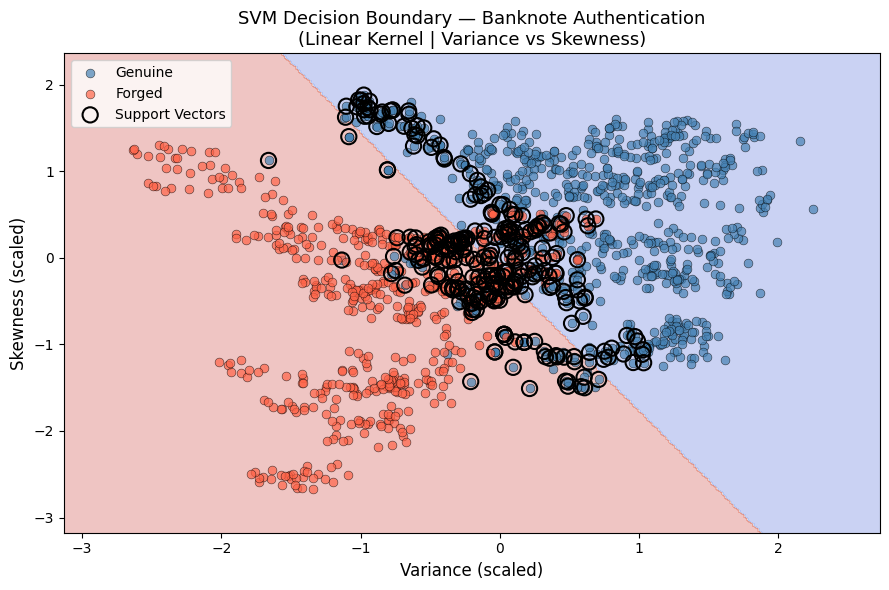

In [ ]:
# Train SVM on 2D features for plotting
svm_plot = SVC(kernel='linear', C=1.0, random_state=42)
svm_plot.fit(X_train_2d, y_train_2d)

# Create mesh grid
x_min, x_max = X_2d_scaled.iloc[:, 0].min() - 0.5, X_2d_scaled.iloc[:, 0].max() + 0.5
y_min, y_max = X_2d_scaled.iloc[:, 1].min() - 0.5, X_2d_scaled.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = svm_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

colors = {0: 'steelblue', 1: 'tomato'}
labels_map = {0: 'Genuine', 1: 'Forged'}
for cls in [0, 1]:
    idx = y == cls
    plt.scatter(
        X_2d_scaled.loc[idx, 'variance'],
        X_2d_scaled.loc[idx, 'skewness'],
        c=colors[cls], label=labels_map[cls],
        edgecolors='k', linewidths=0.4, s=40, alpha=0.7
    )

# Mark support vectors
sv = svm_plot.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none',
            edgecolors='black', linewidths=1.5, label='Support Vectors')

plt.xlabel('Variance (scaled)', fontsize=12)
plt.ylabel('Skewness (scaled)', fontsize=12)
plt.title('SVM Decision Boundary — Banknote Authentication\n(Linear Kernel | Variance vs Skewness)', fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Q13: Visualize Confusion Matrix as Heatmap

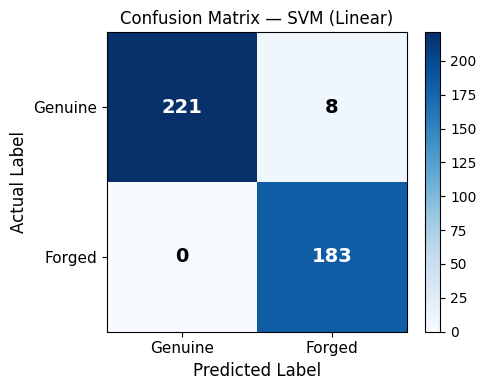

In [ ]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Genuine', 'Forged']

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label',    fontsize=12)
ax.set_title('Confusion Matrix — SVM (Linear)', fontsize=12)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

##Conclusion

> **Dataset:** Banknote Authentication (UCI) - 1372 samples, 4 Wavelet-based features, Binary classification (Genuine / Forged).
>
> **Algorithm:** SVM finds the **optimal hyperplane** that separates classes with the **maximum margin**. Points closest to the hyperplane are called **support vectors** they alone define the boundary.
>
> **Key Findings:**
> - The **Linear kernel** performs very well (~98%+), indicating the two classes are largely linearly separable in feature space.
> - The **RBF kernel** captures non-linear patterns and may yield slightly higher accuracy.
> - **Feature scaling was critical** SVM is sensitive to feature magnitude as it uses distance-based margin optimization.
> - The decision boundary plot clearly shows the separation between Genuine and Forged notes using just Variance and Skewness.
> - **Support Vectors** (circled points on the plot) are the boundary-defining samples removing other points would not change the hyperplane.
